# Imports y Dataset

In [ ]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'instacart-market-basket-analysis' dataset.
Path to dataset files: /kaggle/input/instacart-market-basket-analysis


#Inicialización del dataset

In [ ]:
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
data_dict = {os.path.basename(f).replace('.csv', ''): f for f in csv_files}
print("Archivos encontrados:", list(data_dict.keys()))

df_orders = pd.read_csv(data_dict['orders']).sample(n=50000, random_state=42)
df_order_products = pd.read_csv(data_dict['order_products__train'])
df_products = pd.read_csv(data_dict['products'])

df_merged = pd.merge(df_order_products, df_orders, on='order_id', how='inner')
df = pd.merge(df_merged, df_products, on='product_id', how='inner')

columnas_interes = ['add_to_cart_order', 'reordered', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'department_id']
df = df[columnas_interes].dropna()

print("\nDataset cargado exitosamente en la variable 'df'")

Archivos encontrados: ['products', 'order_products__train', 'orders', 'order_products__prior', 'aisles', 'departments']

Dataset cargado exitosamente en la variable 'df'


#Inspección inicial

In [ ]:
print("--- INFO ---")
df.info()

print("\n--- SHAPE ---")
print(df.shape)

print("\n--- DESCRIBE ---")
print(df.describe())

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20208 entries, 0 to 20207
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   add_to_cart_order       20208 non-null  int64  
 1   reordered               20208 non-null  int64  
 2   order_dow               20208 non-null  int64  
 3   order_hour_of_day       20208 non-null  int64  
 4   days_since_prior_order  20208 non-null  float64
 5   department_id           20208 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 947.4 KB

--- SHAPE ---
(20208, 6)

--- DESCRIBE ---
       add_to_cart_order     reordered     order_dow  order_hour_of_day  \
count       20208.000000  20208.000000  20208.000000       20208.000000   
mean            8.629850      0.593775      2.737431          13.544240   
std             7.110783      0.491140      2.174193           4.218922   
min             1.000000      0.000000      0.000000       

#Graficas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

/tmp/ipykernel_21060/1630290663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='order_hour_of_day', palette='viridis')


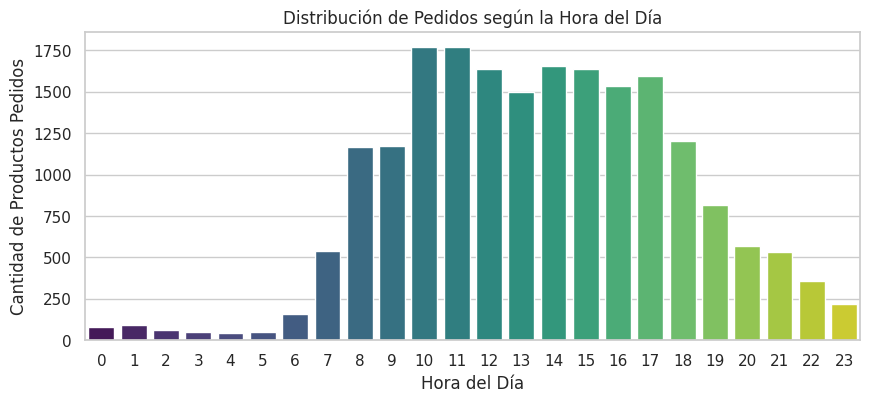

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='order_hour_of_day', palette='viridis')
plt.title('Distribución de Pedidos según la Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Cantidad de Productos Pedidos')
plt.show()

Esta grafica muestra la relación entre cantidad de pedidos y en que hora del dia. Nos sirve para saber el habito de consumo de nuestros clientes.

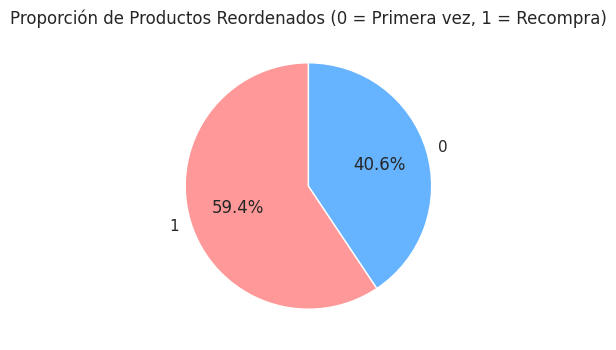

In [ ]:
plt.figure(figsize=(5, 4))
df['reordered'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Proporción de Productos Reordenados (0 = Primera vez, 1 = Recompra)')
plt.ylabel('')
plt.show()

Esta grafica nos muestra que tanto se han recomprado un mismo producto o se ha comprado un producto nuevo, esto nos ayuda a conocer la fidelidad, curiosidad y rango de variedad en compras de los clientes.

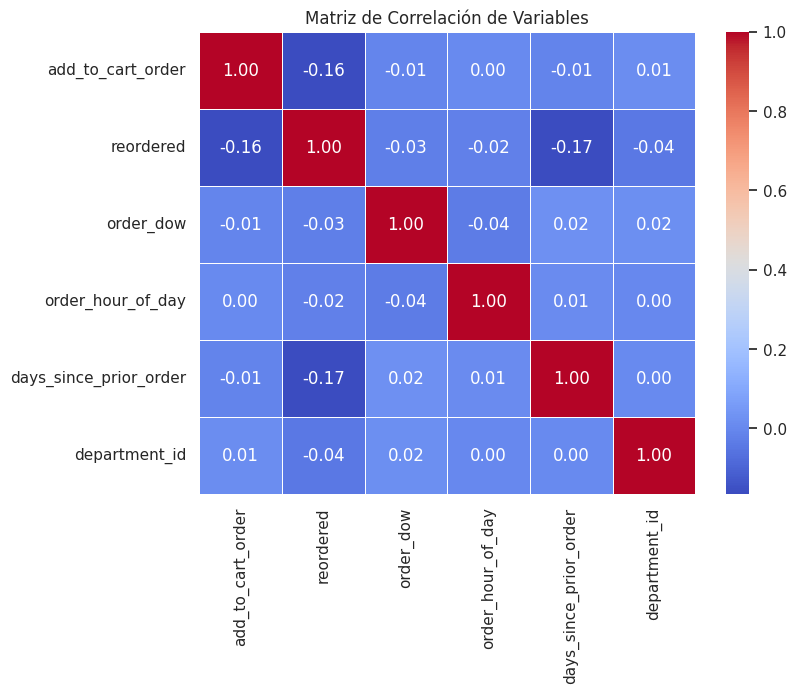

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

Esta grafica nos enseña la matriz de correlación entre variables, algo muy importante sobre todo para el avance del modelo ya que nos permite saber que variables parecen estar relacionadas o verse afectadas entre si.

#Procesamiento de datos

##Justificación:
"department_id" tiene mas de 20 categorias, para agilizar el entrenamiento y evitar desbalances vamos a acortar las categorias a solo las 5 mas populares.

In [ ]:
top_departments = df['department_id'].value_counts().nlargest(5).index
df_filtrado = df[df['department_id'].isin(top_departments)]

X = df_filtrado.drop(columns=['department_id'])
y = df_filtrado['department_id']

print(f"Estructura final de características X: {X.shape}")
print(f"Distribución del objetivo y:\n{y.value_counts(normalize=True)}")

Estructura final de características X: (13997, 5)
Distribución del objetivo y:
department_id
4     0.436665
16    0.224977
19    0.120812
7     0.114667
1     0.102879
Name: proportion, dtype: float64


#Division de datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamaño de Entrenamiento: {X_train.shape}")
print(f"Tamaño de Prueba: {X_test.shape}")

Tamaño de Entrenamiento: (11197, 5)
Tamaño de Prueba: (2800, 5)


#Entrenamiento de modelos

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Modelo 1
print("Entrenando Modelo 1 (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Modelo 2
print("Entrenando Modelo 2 (HistGradientBoosting)...")
hgb_model = HistGradientBoostingClassifier(max_iter=50, random_state=42)
hgb_model.fit(X_train, y_train)

print("¡Modelos entrenados con éxito!")

Entrenando Modelo 1 (Random Forest)...
Entrenando Modelo 2 (HistGradientBoosting)...
¡Modelos entrenados con éxito!


#Evalucación de Métricas

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_rf = rf_model.predict(X_test)
y_pred_hgb = hgb_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

acc_hgb = accuracy_score(y_test, y_pred_hgb)
f1_hgb = f1_score(y_test, y_pred_hgb, average='macro')

print(f"=== RENDIMIENTO RANDOM FOREST ===\nAccuracy: {acc_rf:.4f} | F1-Score (Macro): {f1_rf:.4f}\n")
print(f"=== RENDIMIENTO HIST-GRADIENT BOOSTING ===\nAccuracy: {acc_hgb:.4f} | F1-Score (Macro): {f1_hgb:.4f}\n")

print("COMENTARIO DE MÉTRICAS:")
print("El Accuracy nos indica el porcentaje total de aciertos. Sin embargo, al tener clases con diferente volumen,")
print("el F1-Score Macro es más confiable porque evalúa el desempeño del modelo en cada departamento por separado")
print("y saca un promedio, evitando que una clase dominante infle artificialmente el resultado.")

=== RENDIMIENTO RANDOM FOREST ===
Accuracy: 0.4411 | F1-Score (Macro): 0.1767

=== RENDIMIENTO HIST-GRADIENT BOOSTING ===
Accuracy: 0.4464 | F1-Score (Macro): 0.1901

COMENTARIO DE MÉTRICAS:
El Accuracy nos indica el porcentaje total de aciertos. Sin embargo, al tener clases con diferente volumen,
el F1-Score Macro es más confiable porque evalúa el desempeño del modelo en cada departamento por separado
y saca un promedio, evitando que una clase dominante infle artificialmente el resultado.


#Guardado de modelos

In [ ]:
import joblib


file_rf = "modelo_random_forest.pkl"
file_hgb = "modelo_gradient_boosting.pkl"


joblib.dump(rf_model, file_rf)
joblib.dump(hgb_model, file_hgb)

print(f"Modelo 1 guardado como: {file_rf}")
print(f"Modelo 2 guardado como: {file_hgb}")

Modelo 1 guardado como: modelo_random_forest.pkl
Modelo 2 guardado como: modelo_gradient_boosting.pkl
